<div style="background:#0b3d91;color:white;padding:60px 70px;margin:-60px -70px;">

# PSE-823: Advanced Process Dynamics and Control

### Lecture 1 &mdash; Introductory Concepts & Modeling Tools for Process Dynamics
#### Coughanowr & LeBlanc, Chapters 1&ndash;2

**Haider Ejaz**

</div>


## Welcome

**Instructor:** Haider Ejaz, PhD &mdash; Office: Room 220 &middot; Email: haider.ejaz@scme.nust.edu.pk

- This is the first offering of PSE-823 for the MS program.
- We'll build on the single-loop control ideas from instrumentation/process-control
  courses and push toward multivariable and model-predictive control.
- Python will be a running thread throughout the course &mdash; alongside the theory,
  we'll simulate, tune, and visualize every major concept we cover.


### About Me

![About Me](images/instructor_about_me.jpg)


## Course Contents

| Block | Topics |
|---|---|
| **Modeling for Process Dynamics** | Modeling tools, inversion by partial fractions |
| **Linear Open/Closed-Loop Systems** | 2nd-order & transportation lag, the control system, controllers & final control elements, block diagram of a reactor control loop, measurement lag, stability |
| **Frequency Response** | Control system design by frequency response (Bode, gain/phase margin) |
| **State-Space Methods** | State-space representation, transfer function matrix, multivariable control |
| **Nonlinear Control** | Nonlinear system case studies, phase-plane analysis |
| **Process Applications** | Advanced control strategies, controller tuning & process ID, complex processes |
| **Computers in Process Control** | Microprocessor-based & distributed control |


## Course Objectives & Outcomes

**Objectives**
- Build an in-depth understanding of automatic process control &mdash; essential to safe,
  economical, and environmentally sound plant operation.
- Understand the need and challenges of controlling complex, highly integrated
  modern industrial processes.

**Outcomes**
- Bridges basic single-loop control and **Model Predictive Control (MPC)**.
- Economic aspects of advanced control technologies are stressed throughout.


## Evaluation

| Component | Weight |
|---|---|
| Quizzes | 10% |
| Assignments | 20% |
| Midterm Exam | 20% |
| Final Exam | 50% |

*Breakdown shown is the typical NUST MS structure and may be adjusted once the final
course outline is submitted.*


## Recommended Reading

- **Primary:** LeBlanc, S.E. & Coughanowr, D.R. &mdash; *Process Systems Analysis and
  Control*, 3rd ed. (matches this course almost chapter-for-chapter)
- Smith, Cecil L. &mdash; *Advanced Process Control: Beyond Single Loop Control*
  (our source for Model Predictive Control, Section 8.3)
- Roffel, B. & Betlem, B.H. &mdash; *Advanced Practical Process Control*


## Python in this Course

- **`python-control`** &mdash; transfer functions, block-diagram algebra, time/frequency
  response, root locus, state-space
- **GEKKO** &mdash; dynamic optimization and Model Predictive Control
- `numpy`, `scipy`, `matplotlib`, `sympy` &mdash; the general-purpose toolkit

We will use these throughout the semester to simulate the systems we derive by hand
&mdash; starting today, with the two chemical mixing examples from Chapter 2.


<div style="background:#0b3d91;color:white;padding:80px 70px;margin:-60px -70px;text-align:center;">

# Chapter 1
## Introductory Concepts

</div>


### Concept &mdash; Why Process Control?

Automatic control exists because manual operation can't keep up with modern,
competitive chemical plants. It buys us:

- Enhanced **process safety**
- Satisfying **environmental** constraints
- Meeting strict **product quality** specifications
- Efficient use of **raw materials and energy**
- Increased **profitability**


### Concept &mdash; Control System Vocabulary

A control system's job: keep a **controlled variable** at its **set point**, by
adjusting a **manipulated variable**, in spite of **disturbances**.

- **Disturbance rejection** &mdash; hold the controlled variable steady despite disturbances
- **Set point tracking** &mdash; follow the controlled variable to a *new* desired value

The controller compares a **measurement signal** of the controlled variable to the
set point; the difference is the **error**:

$$\text{Error} = (\text{Set point}) - (\text{Measured value})$$


### Example &mdash; The Generalized Control Loop

Using information about the deviation of the system from its desired state to
correct the system is called **feedback control**.

![Fig 1-1: generalized block diagram](images/fig1-1_block_diagram.jpeg)

**Closed-loop** &mdash; the controller automatically acts on the measurement to restore
the set point. **Open-loop** ("manual mode") &mdash; the measurement path is disconnected;
a human must adjust the output by hand.

Almost all the feedback we use is **negative feedback**: error = set point &minus;
measurement. (*Positive* feedback is usually undesirable and tends toward instability.)


### Your Turn (8 min)

Pick **one**: a car's cruise control, OR a toilet tank's water-level control.

On paper, sketch the block diagram (boxes + arrows, following the structure above)
and label:

- Controlled variable
- Set point
- Manipulated variable
- Disturbance(s)
- Measurement device


**Answer key**

Cruise control: controlled var = vehicle speed; manipulated var = throttle/fuel
flow; disturbances = hills, wind, terrain; measurement = speedometer/wheel sensor.

Toilet tank: controlled var = water level; manipulated var = fill-valve opening;
disturbance = flush event; measurement = float.

Watch for: students forgetting the measurement/feedback path entirely, or mixing up
manipulated vs. controlled variable.


### Check

Cold-call 2 students &mdash; one on cruise control, one on toilet tank. Have them name
their four blocks out loud without looking at notes.

Ask a third: *"What would happen if we disconnected the feedback signal &mdash; is that
still a control system?"*


Answer: yes, but it becomes **open-loop** / "manual mode" &mdash; the controller output
has to be adjusted by hand rather than automatically correcting itself.


### Example &mdash; Hot Water Heater (On/Off Control)

Set point $\approx 130^\circ F$. Thermostat computes:

$$\text{Error} = T_{setpoint} - T_{measured}$$

- Error $> 0$ &rarr; open fuel valve, add heat
- Error $\le 0$ &rarr; close fuel valve

This is an **on/off controller** &mdash; output is only "full on" or "full off," no
intermediate values.

![Fig 1-2: hot water heater](images/fig1-2_hot_water_heater.jpeg)


### The Full Loop, Block-Diagram Form

![Fig 1-3: block diagram of the hot water heater control system](images/fig1-3_block_diagram_heater.jpeg)


### Your Turn (6 min)

For each scenario, write **open-loop** or **closed-loop**, and justify in one
sentence:

(a) A space heater with a fixed dial, no thermostat.

(b) A home thermostat-controlled furnace.

(c) A manually adjusted oven where *you* check the thermometer and turn the dial.


(a) open-loop &mdash; no feedback path at all, output fixed regardless of room temp.

(b) closed-loop &mdash; thermostat measures and automatically adjusts.

(c) Trick case: this IS technically closed-loop, but the human is the
controller/feedback element &mdash; worth a class discussion on whether "automatic" is
required for "closed-loop."


### Check

Quick poll (show of hands): for scenario (c), how many say open-loop vs.
closed-loop?

Discuss the disagreement &mdash; the loop *is* closed, but nothing about the definition
requires the controller to be a machine.


### Concept &mdash; Proportional and Integral Control

**Proportional control**: change heat input by an amount proportional to the error.

- Larger controller gain &rarr; smaller steady-state error
- A P-only controller can **never** drive error exactly to zero &rarr; residual **offset**

**Integral control** (added on top of P): change input by an amount proportional to
the **time integral** of the error.

- Eliminates steady-state offset
- Trade-off: response tends to be more **oscillatory**, and can even become unstable


### Example &mdash; Offset in Action

Set point $= 130^\circ F$. A disturbance drops the tank temperature to $120^\circ F$.

With **proportional control only**, the system stabilizes &mdash; but not exactly at
$130^\circ F$. It might settle at $127^\circ F$ or $133^\circ F$. That residual gap is
the **offset**.

Adding **integral control** removes this offset entirely, at the cost of a more
oscillatory (overshoot-prone) response on the way there.


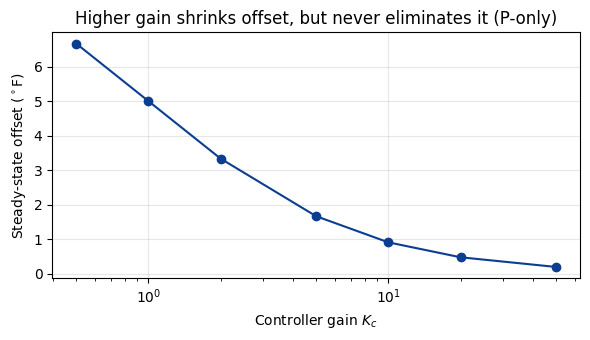

In [1]:
# Quick illustration: proportional-only control always leaves an offset.
# Closed-loop steady-state offset for a first-order process under P-only control:
#   offset = d * Gd(0) / (1 + Kc*Kp)
# The larger Kc, the smaller (but never zero) the offset.

import numpy as np
import matplotlib.pyplot as plt

d = 10.0          # size of the disturbance (deg F)
Gp0 = 1.0         # steady-state process gain (illustrative)
Gd0 = 1.0         # steady-state disturbance gain (illustrative)

Kc_values = np.array([0.5, 1, 2, 5, 10, 20, 50])
offset = d * Gd0 / (1 + Kc_values * Gp0)

plt.figure(figsize=(6, 3.5))
plt.semilogx(Kc_values, offset, "o-", color="#0b3d91")
plt.xlabel("Controller gain $K_c$")
plt.ylabel("Steady-state offset ($^\circ$F)")
plt.title("Higher gain shrinks offset, but never eliminates it (P-only)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Your Turn (7 min)

Two identical hot-water-heater systems experience the same $10^\circ F$ disturbance.

- System A uses proportional control only, gain = **low**.
- System B uses proportional control only, gain = **high**.

On paper, sketch (qualitatively &mdash; no numbers needed) the temperature-vs-time
response you'd expect for each. Which has smaller offset? Which is more likely to
oscillate or go unstable?


Higher gain &rarr; smaller offset, but a more oscillatory response, and if gain is
pushed too far, the response can become unstable (amplitude grows instead of
settling). This previews the stability discussion formalized later in the course
(Ch. 13, Routh test).


### Check

Think-pair-share (3 min), then cold-call one pair: *"Why can't we just always use a
very high gain to kill the offset?"*


Because increasing gain also increases the tendency toward oscillation/instability
&mdash; there's a design trade-off, not a free lunch. This is the seed of everything the
rest of the course formalizes.


<div style="background:#0b3d91;color:white;padding:80px 70px;margin:-60px -70px;text-align:center;">

# Chapter 2
## Modeling Tools for Process Dynamics

</div>


### Concept &mdash; Why Modeling?

Before we can control a process, we need to **predict how it behaves over time**
&mdash; that's process dynamics.

Our first modeling tool: the **unsteady-state mass balance**.

$$\text{Rate in} - \text{Rate out} = \text{Accumulation}$$

For a well-mixed tank with constant volume and flow, this reduces to a first-order
linear ODE in terms of the tank's **residence time** $\tau = V/v$.


### Example &mdash; A Chemical Mixing Scenario

Two process streams mix, feed a heating vessel ($V = 150$ L), then go to a reactor.

![Fig 2-1: process flow diagram](images/fig2-1_mixing_process.jpeg)

At 3:00 PM, an operator swaps the flow rates of streams 1 and 2:
before $v_1=10$, $v_2=20$ L/min &rarr; after $v_1=20$, $v_2=10$ L/min.
Concentrations: $C_{a1}=1$, $C_{a2}=4$ g/L.


### Steady-State Balance Around the Mixing Tee

$$v_1 C_{a1} + v_2 C_{a2} = v_3 C_{a3}$$

**Before:** $(10)(1) + (20)(4) = 30\,C_{a3} \;\Rightarrow\; C_{a3} = 3$ g/L

**After:** $(20)(1) + (10)(4) = 30\,C_{a3} \;\Rightarrow\; C_{a3} = 2$ g/L

![Fig 2-2: operator-induced transient](images/fig2-2_mixing_transient.jpeg)

The tank doesn't jump instantly from 3 to 2 g/L &mdash; it *transitions*.


### Deriving the Transient: Unsteady Mass Balance on the Heating Vessel

$$v_3 C_{a3} - v_3 C_a = \frac{d}{dt}(V C_a)$$

Since $v$ is constant in and out, $V$ is constant, and this rearranges to

$$\frac{V}{v_3}\frac{dC_a}{dt} + C_a = C_{a3}, \qquad \tau = \frac{V}{v_3} = \frac{150}{30} = 5\ \text{min}$$

$$5\frac{dC_a}{dt} + C_a = 2, \qquad C_a(0) = 3\ \text{g/L}$$

Separating and integrating gives

$$C_a(t) = 2 + e^{-t/5}$$


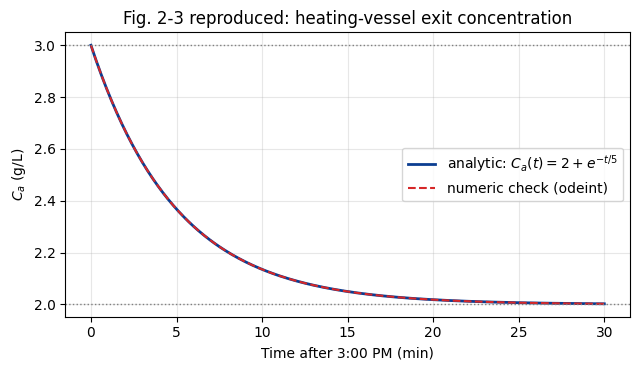

Ca(0) = 3.000 g/L,  Ca(inf) -> 2.002 g/L (should approach 2.0 g/L)


In [2]:
# Solve and plot the mixing-tank concentration transient (Eq. 2.1-2.2), reproducing Fig 2-3.
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

tau = 5.0        # min, residence time V/v3
Ca3 = 2.0        # g/L, new (post-disturbance) feed concentration
Ca0 = 3.0        # g/L, initial (steady-state) concentration in the tank

def dCadt(Ca, t):
    return (Ca3 - Ca) / tau

t_sim = np.linspace(0, 30, 300)
Ca_numeric = odeint(dCadt, Ca0, t_sim).flatten()
Ca_analytic = Ca3 + (Ca0 - Ca3) * np.exp(-t_sim / tau)

plt.figure(figsize=(6.5, 3.8))
plt.plot(t_sim, Ca_analytic, color="#0b3d91", lw=2, label=r"analytic: $C_a(t)=2+e^{-t/5}$")
plt.plot(t_sim, Ca_numeric, "--", color="#d62728", lw=1.5, label="numeric check (odeint)")
plt.axhline(3, color="gray", ls=":", lw=1)
plt.axhline(2, color="gray", ls=":", lw=1)
plt.xlabel("Time after 3:00 PM (min)")
plt.ylabel(r"$C_a$ (g/L)")
plt.title("Fig. 2-3 reproduced: heating-vessel exit concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ca(0) = {Ca_analytic[0]:.3f} g/L,  Ca(inf) -> {Ca_analytic[-1]:.3f} g/L (should approach {Ca3} g/L)")

### Your Turn (12 min)

Same mixing tee and heating vessel ($V=150$ L, $v_3=30$ L/min, $\tau=5$ min).

At 4:00 PM a *different* operator error occurs: stream 1 flow is mistakenly
increased from 10 to **20 L/min**, while stream 2 (20 L/min, 4 g/L) and stream 1's
concentration (1 g/L) stay unchanged.

1. Find the new steady-state $C_{a3}$ feeding the heating vessel.
2. Write and solve the ODE for $C_a(t)$, given $C_a(0) = 3$ g/L.
3. Sanity check: does $C_a(t)$ approach a sensible value as $t \to \infty$?


$v_3 = v_1+v_2 = 40$ L/min now &mdash; careful, this changes $\tau$ too:
new $\tau = V/v_3 = 150/40 = 3.75$ min.

$C_{a3,new} = [20(1)+20(4)]/40 = 2.5$ g/L.

ODE: $3.75\,dC_a/dt + C_a = 2.5$, $C_a(0)=3 \Rightarrow C_a(t) = 2.5 + 0.5\,e^{-t/3.75}$.

Common mistake: students forget $v_3$ (and therefore $\tau$) changed along with the
flow rates &mdash; easy to reuse $\tau=5$ min from the worked example without noticing
$v_3$ is no longer 30 L/min.

Sanity check: as $t\to\infty$, $C_a\to 2.5$ g/L, between the two inlet
concentrations &mdash; reasonable.


In [3]:
# Self-check cell for the "Your Turn" above -- students can fill in v1_new/v2_new
# and confirm their hand derivation against a quick simulation.

v1_new, Ca1 = 20.0, 1.0     # L/min, g/L
v2_new, Ca2 = 20.0, 4.0     # L/min, g/L
V = 150.0                   # L

v3_new = v1_new + v2_new
tau_new = V / v3_new
Ca3_new = (v1_new * Ca1 + v2_new * Ca2) / v3_new

t_sim = np.linspace(0, 20, 200)
Ca_t = Ca3_new + (3.0 - Ca3_new) * np.exp(-t_sim / tau_new)

print(f"v3_new  = {v3_new:.2f} L/min")
print(f"tau_new = {tau_new:.3f} min   (NOT 5 min anymore!)")
print(f"Ca3_new = {Ca3_new:.3f} g/L")
print(f"Ca(t->inf) -> {Ca_t[-1]:.3f} g/L")

v3_new  = 40.00 L/min
tau_new = 3.750 min   (NOT 5 min anymore!)
Ca3_new = 2.500 g/L
Ca(t->inf) -> 2.502 g/L


### Check

Cold-call one student for their value of $\tau$. If they say "5 min," ask them to
re-check $v_3$.

Cold-call a second for the final steady-state value and ask them to justify it
physically (should lie between the two inlet concentrations, weighted by flow).


### Concept &mdash; The Energy Balance Analog

The same balance logic applies to **energy**: replace "mass of A" with "enthalpy,"
and you get an analogous first-order ODE for temperature.

$$\text{Rate of enthalpy in} - \text{Rate of enthalpy out} + Q = \text{Accumulation}$$

Steady-state balance around the mixing tee gives the blended stream's temperature;
balance around the heated vessel (with heater duty $Q$) gives the outlet
temperature dynamics.


### Example &mdash; Steady State

Stream 1 at $25^\circ C$, Stream 2 at $55^\circ C$.

$$T_3 = \frac{v_1 T_1 + v_2 T_2}{v_3} = \frac{(10)(25)+(20)(55)}{30} = 45^\circ C$$

![Fig 2-4: initial temperatures](images/fig2-4_initial_temps.jpeg)

Heater brings this up to $80^\circ C$ at steady state:

$$Q = \rho v_3 C_p (T - T_3) = (1000)(30)(1)(80-45) = 1.05\times10^6\ \text{cal/min} \approx 73.2\ \text{kW}$$

![Fig 2-5: steady-state energy balance summary](images/fig2-5_energy_balance_summary.jpeg)


### After the Disturbance

Flows swap ($v_1=20$, $v_2=10$ L/min) &mdash; same swap as the mass-balance example:

$$T_3 = \frac{(20)(25)+(10)(55)}{30} = 35^\circ C$$

![Fig 2-6: inlet temperature disturbance](images/fig2-6_inlet_temp_disturbance.jpeg)

With $Q$ and $v_3$ unchanged, the unsteady energy balance on the heating vessel
gives:

$$\left(\frac{V}{v_3}\right)\frac{dT}{dt} + T = T_3 + \frac{Q}{\rho v_3 C_p}
= 35 + 35 = 70^\circ C$$

$$5\frac{dT}{dt} + T = 70, \qquad T(0)=80^\circ C \;\;\Rightarrow\;\; T(t) = 70 + 10e^{-t/5}$$


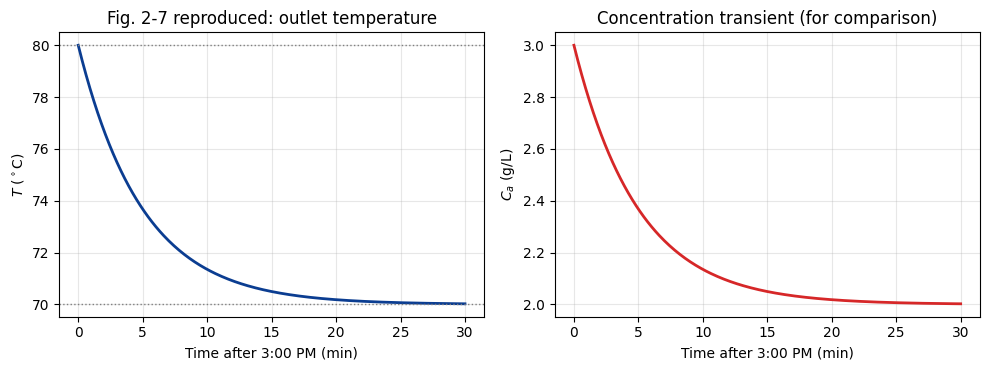

Same tau (5 min) drives both transients -- same exponential SHAPE, different physical variable and endpoints.


In [4]:
# Solve and plot the mixing-tank temperature transient (Eq. 2.3-2.4), reproducing Fig 2-7,
# alongside the concentration transient for comparison -- same tau, same exponential shape.

tau = 5.0
T3, Q_over_rvCp = 35.0, 35.0   # deg C ;  Q/(rho*v3*Cp) = 1.05e6/(1000*30*1) = 35 C
T_ss_input = T3 + Q_over_rvCp  # = 70 C
T0 = 80.0

t_sim = np.linspace(0, 30, 300)
T_t = T_ss_input + (T0 - T_ss_input) * np.exp(-t_sim / tau)
Ca_t = 2.0 + (3.0 - 2.0) * np.exp(-t_sim / tau)   # from the earlier mass-balance example

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].plot(t_sim, T_t, color="#0b3d91", lw=2)
axes[0].axhline(80, color="gray", ls=":", lw=1)
axes[0].axhline(70, color="gray", ls=":", lw=1)
axes[0].set_xlabel("Time after 3:00 PM (min)")
axes[0].set_ylabel(r"$T$ ($^\circ$C)")
axes[0].set_title("Fig. 2-7 reproduced: outlet temperature")
axes[0].grid(alpha=0.3)

axes[1].plot(t_sim, Ca_t, color="#d62728", lw=2)
axes[1].set_xlabel("Time after 3:00 PM (min)")
axes[1].set_ylabel(r"$C_a$ (g/L)")
axes[1].set_title("Concentration transient (for comparison)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Same tau (5 min) drives both transients -- same exponential SHAPE, different"
      " physical variable and endpoints.")

### Your Turn (10 min)

Using the *original* flow configuration ($v_1=10$ L/min at $25^\circ C$, $v_2=20$
L/min at $55^\circ C$, $v_3=30$ L/min, $V=150$ L):

Suppose at 5:00 PM the operator changes stream 1's temperature to $40^\circ C$
(flows unchanged).

1. Find the new steady-state $T_3$.
2. Set up (don't need to fully solve) the ODE for $T(t)$, given $T(0)=80^\circ C$
   and fixed steady heater duty $Q$.


$T_{3,new} = [(10)(40)+(20)(55)]/30 = 50^\circ C$.

$\tau\,dT/dt + T = T_3 + Q/(\rho v_3 C_p)$, $\tau=5$ min **unchanged**, since flows
did not change this time (contrast with the mass-balance task where flows DID
change $\tau$ &mdash; worth pointing out explicitly as the two-sided version of the same
judgment check).


### Check

Poll: *"Did $\tau$ change in this scenario?"* (Compare with the earlier
mass-balance task where it did.)

Discuss why: $\tau = V/v_3$ depends only on flow rates, not on which stream's
temperature or concentration changed.


### Concept &mdash; The Laplace Transform

Solving these ODEs by hand (separation of variables) works, but gets painful fast
for higher-order systems. The **Laplace transform** converts a linear ODE into an
*algebraic* equation.

$$F(s) = \mathcal{L}\{f(t)\} = \int_0^\infty f(t)\,e^{-st}\,dt$$

Key property &mdash; it's **linear**:

$$\mathcal{L}\{a f_1(t) + b f_2(t)\} = a\,\mathcal{L}\{f_1(t)\} + b\,\mathcal{L}\{f_2(t)\}$$


### Example &mdash; Deriving $\mathcal{L}\{1\}$ From the Definition

$$F(s) = \int_0^\infty (1)e^{-st}\,dt = \left[\frac{-e^{-st}}{s}\right]_0^\infty = \frac{1}{s}$$

So $\mathcal{L}\{u(t)\} = \dfrac{1}{s}$, and by linearity,
$\mathcal{L}\{A\cdot u(t)\} = \dfrac{A}{s}$ for any constant $A$.


In [5]:
# Verify the by-hand derivation symbolically -- this is the Python analogue of
# MATLAB's `syms` + `laplace`, which the textbook also demonstrates.
import sympy as sp

t, s, a, k = sp.symbols("t s a k", positive=True, real=True)

f1 = sp.Heaviside(t)          # unit step u(t)
F1 = sp.laplace_transform(f1, t, s, noconds=True)
print("L{u(t)} =", F1)        # should be 1/s

f2 = sp.exp(-a * t) * sp.Heaviside(t)
F2 = sp.laplace_transform(f2, t, s, noconds=True)
print("L{e^(-a t) u(t)} =", F2)   # should be 1/(s+a)

L{u(t)} = 1/s
L{e^(-a t) u(t)} = 1/(a + s)


### Your Turn (10 min)

Using the same integral definition, derive $\mathcal{L}\{e^{-at}u(t)\}$ from
scratch (don't just look it up in a table &mdash; show the integration).

Then use your result to write down $\mathcal{L}\{e^{-3t}\}$ as a specific
number-filled expression.


$\int_0^\infty e^{-at}e^{-st}\,dt = \int_0^\infty e^{-(s+a)t}\,dt = \dfrac{1}{s+a}$,
valid for $s > -a$.

$\mathcal{L}\{e^{-3t}\} = \dfrac{1}{s+3}$.

Common mistake: sign errors combining the two exponents, or forgetting the
validity condition on $s$.


In [6]:
# Students: check your by-hand answer against sympy once you've derived it.
F_check = sp.laplace_transform(sp.exp(-3 * t) * sp.Heaviside(t), t, s, noconds=True)
print("L{e^(-3t)} =", F_check)   # confirm it matches 1/(s+3)

L{e^(-3t)} = 1/(s + 3)


### Check

Cold-call a student to write their derivation on the board, step by step. Ask a
second to state the validity condition ($s > -a$) and why it matters (the integral
must converge).


### Concept &mdash; Transforming Derivatives

The real payoff: Laplace transforms **derivatives**, turning differentiation into
multiplication by $s$.

$$\mathcal{L}\left\{\frac{df}{dt}\right\} = sF(s) - f(0)$$

This lets us convert a differential equation into a purely algebraic one. The
general **3-step procedure**:

1. Transform both sides of the ODE (initial conditions enter here)
2. Solve algebraically for the transform of the unknown
3. **Invert** the transform back to a function of $t$ (often the hardest step &mdash;
   partial fractions, covered in Ch. 3)


### Example &mdash; Applying the Procedure to the Mixing-Tank ODE

$$\tau\frac{dC_a}{dt} + C_a = C_{a3}$$

**Step 1 &mdash; transform** (with $C_a(0)$ as the initial condition):

$$\tau[sC_a(s) - C_a(0)] + C_a(s) = C_{a3}(s)$$

**Step 2 &mdash; solve algebraically:**

$$C_a(s) = \frac{C_{a3}(s) + \tau\,C_a(0)}{\tau s + 1}$$

Plug in $C_{a3}(s)=2/s$, $C_a(0)=3$, $\tau=5$:

$$C_a(s) = \frac{2}{5s+1} + \frac{15}{5s+1}$$

**Step 3 (inverting)** is Chapter 3's job &mdash; but we can check it numerically now.


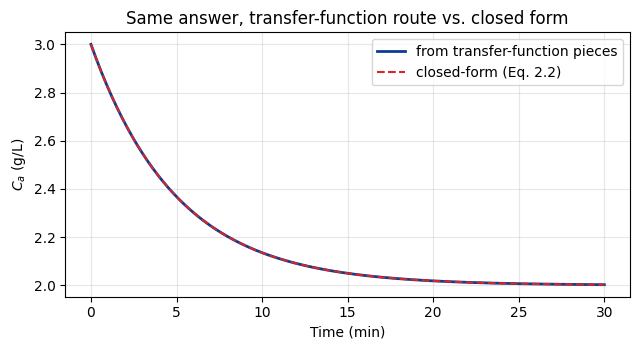

In [7]:
# Preview: python-control lets us build C_a(s) directly as a transfer function
# and simulate its step response -- no partial fractions needed yet. This is
# exactly the kind of "solve algebraically, then simulate" workflow we'll use
# heavily starting next lecture.
import control as ct

tau = 5.0
Ca0 = 3.0
Ca3_final = 2.0

# Ca(s) = [Ca3(s) + tau*Ca0] / (tau*s + 1),  with Ca3(s) = Ca3_final/s  (step input)
# => Ca(s) = Ca3_final/(s*(tau*s+1))  +  tau*Ca0/(tau*s+1)
G1 = ct.tf([Ca3_final], [tau, 1, 0])     # Ca3_final / (s*(tau*s+1))  -- forced response to unit step...
G2 = ct.tf([tau * Ca0], [tau, 1])        # tau*Ca0 / (tau*s+1)        -- decaying IC contribution

t_sim = np.linspace(0, 30, 300)
_, y1 = ct.step_response(ct.tf([1], [tau, 1]), T=t_sim)   # response of 1/(tau s+1) to a unit step
Ca_s_domain = Ca3_final * y1 + Ca0 * np.exp(-t_sim / tau)

plt.figure(figsize=(6.5, 3.6))
plt.plot(t_sim, Ca_s_domain, color="#0b3d91", lw=2, label="from transfer-function pieces")
plt.plot(t_sim, 2 + np.exp(-t_sim / 5), "--", color="#d62728", lw=1.5, label="closed-form (Eq. 2.2)")
plt.xlabel("Time (min)")
plt.ylabel(r"$C_a$ (g/L)")
plt.title("Same answer, transfer-function route vs. closed form")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Your Turn (10 min)

Take the ODE you set up two cycles ago for the temperature transient:

$$\tau\frac{dT}{dt} + T = T_3 + \frac{Q}{\rho v_3 C_p}, \qquad
\tau=5\ \text{min},\ T(0)=80^\circ C,\ T_3=50^\circ C\ (\text{constant})$$

Apply steps 1&ndash;2: transform the equation and solve algebraically for $T(s)$.
Leave symbols where you don't have a number (e.g. for the $Q/(\rho v_3 C_p)$ term)
&mdash; you don't need to invert it.


$\tau[sT(s)-T(0)] + T(s) = T_3(s) + \dfrac{1}{\rho v_3 C_p}Q(s)$

$T(s)(\tau s+1) = T_3/s + \tau\,T(0) + \dfrac{1}{\rho v_3 C_p}\cdot\dfrac{Q}{s}$
(since $T_3, Q$ are step/constant &rarr; divide by $s$)

$T(s) = \dfrac{T_3/s + 5(80) + \frac{1}{\rho v_3 C_p}\cdot\frac{Q}{s}}{5s+1}$

Common mistake: forgetting that $T_3$ and $Q$ are themselves step functions
(constant for $t>0$), so *their* transforms are also divided by $s$, not just
plugged in as bare numbers.


### Check

Cold-call a student to walk through their transform step by step. Ask specifically:
*"Why does $T_3$ appear as $T_3/s$ and not just $T_3$?"* &mdash; checks whether they
understood the step-function transform, not just pattern-matched the earlier
example.


### Concept &mdash; Transform Tables & Symbolic Tools

You won't derive every transform from the integral definition in practice &mdash;
**Table 2.1** collects the standard ones (step, ramp, exponential, sine, cosine,
and their damped/hyperbolic variants). Use it as a lookup toolbox, just like a
table of standard integrals.

| Tool | MATLAB | Python (`sympy`) |
|---|---|---|
| Forward transform | `laplace(f)` | `sp.laplace_transform(f, t, s)` |
| Inverse transform | `ilaplace(F)` | `sp.inverse_laplace_transform(F, s, t)` |
| Solve ODE symbolically | `dsolve(...)` | `sp.dsolve(...)` |


In [8]:
# The textbook's worked ODE example (Example 2.2 / Eq. 2.7-2.9), done the Python way --
# mirroring the book's MATLAB dsolve/ilaplace demonstration.
x = sp.Function("x")
ode = sp.Eq(x(t).diff(t, 3) + 4 * x(t).diff(t, 2) + 5 * x(t).diff(t) + 2 * x(t), 2)
ics = {x(0): 0, x(t).diff(t).subs(t, 0): 0, x(t).diff(t, 2).subs(t, 0): 0}

solution = sp.dsolve(ode, x(t), ics=ics)
print("x(t) =", sp.simplify(solution.rhs))
# Book's closed-form answer (Eq. 2.8): x(t) = 1 - 2*t*exp(-t) - exp(-2*t)

x(t) = -2*t*exp(-t) + 1 - exp(-2*t)


### Your Turn (5 min)

Without doing any integration, use Table 2.1 to write down the transforms of:

(a) $5t$ (a ramp scaled by 5)

(b) $3e^{-2t}$

(c) $\sin(4t)$


(a) $5/s^2$

(b) $3/(s+2)$

(c) $4/(s^2+16)$

This is a fast, low-stakes cycle to close on &mdash; mostly confidence-building lookup
practice before Ch. 3 (partial fractions) gets harder.


In [9]:
# Instant self-check for the Your Turn above.
for expr, label in [
    (5 * t, "5t"),
    (3 * sp.exp(-2 * t), "3*e^(-2t)"),
    (sp.sin(4 * t), "sin(4t)"),
]:
    F = sp.laplace_transform(expr * sp.Heaviside(t), t, s, noconds=True)
    print(f"L{{{label}}} = {F}")

L{5t} = 5/s**2
L{3*e^(-2t)} = 3/(s + 2)
L{sin(4t)} = 4/(s**2 + 16)


### Check

Quick poll &mdash; show of hands on each part as you reveal the answers, to catch
anyone still integrating from scratch instead of using the table.


## Wrap-up

**Covered today**

- Control system vocabulary: set point, error, controlled/manipulated variable,
  disturbance
- Closed-loop vs. open-loop, negative feedback
- Proportional control &rarr; offset; integral control removes offset but risks
  oscillation/instability
- Unsteady-state mass & energy balances &rarr; first-order ODEs, residence time $\tau$
- Laplace transform: definition, linearity, transforming derivatives
- The 3-step ODE-solving procedure (transform &rarr; solve algebraically &rarr; invert)
- Transform tables and symbolic tools (`sympy`, and MATLAB's `laplace`/`ilaplace`/`dsolve`)

**Next class:** Chapter 3 &mdash; Inversion by Partial Fractions. This is where we
finally invert the $C_a(s)$ and $T(s)$ expressions we set up today back into
$C_a(t)$ and $T(t)$.
